In [11]:
import pandas as pd
import numpy as np

history_prefix = "training_history_"

In [12]:
import os
import glob
import re

# Define the path to the mirt-fitting results
results_path = "/home/azureuser/cloudfiles/code/Users/manhductranvu/reeval-multi/result/mirt-fitting"

# Get all CSV files starting with the history prefix and containing any k-factor
csv_pattern = os.path.join(results_path, f"{history_prefix}*_k*.csv")
csv_files = glob.glob(csv_pattern)

print(f"Found {len(csv_files)} CSV files with prefix '{history_prefix}' and k-factors")

# List to store individual dataframes
dataframes = []

# Read each CSV file and add scenario column
for csv_file in csv_files:
    # Extract filename without path
    filename = os.path.basename(csv_file)
    
    # Extract k-factor from filename
    k_match = re.search(r'_k(\d+)', filename)
    if not k_match:
        continue  # Skip files without k-factor
    
    k_factor = int(k_match.group(1))
    
    # Extract scenario name: remove prefix and k-factor suffix
    scenario = filename.replace(history_prefix, "").replace(".csv", "")
    scenario = re.sub(r'_k\d+$', '', scenario)  # Remove _k followed by digits
    
    # Read the CSV file
    df = pd.read_csv(csv_file)
    
    # Add scenario and k_factor columns
    df['scenario'] = scenario
    df['k_factor'] = k_factor
    
    # Add to list
    dataframes.append(df)
    
# Combine all dataframes
combined_df = pd.concat(dataframes, ignore_index=True)

print(f"\nCombined DataFrame shape: {combined_df.shape}")
print(f"Unique scenarios: {combined_df['scenario'].nunique()}")
print(f"Available k-factors: {sorted(combined_df['k_factor'].unique())}")
print(f"Scenarios: {sorted(combined_df['scenario'].unique())}")

# Display first few rows
print("\nFirst 5 rows of combined data:")
combined_df.head()

Found 93 CSV files with prefix 'training_history_' and k-factors

Combined DataFrame shape: (19522, 5)
Unique scenarios: 23
Available k-factors: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Scenarios: ['air_bench_2024', 'babi_qa', 'bbq', 'boolq', 'civil_comments', 'combined_data', 'commonsense', 'dyck_language_np=3', 'entity_data_imputation', 'entity_matching', 'gsm', 'imdb', 'legal_support', 'legalbench', 'lsat_qa', 'math', 'med_qa', 'mmlu', 'raft', 'synthetic_reasoning', 'thai_exam', 'truthful_qa', 'wikifact']

First 5 rows of combined data:


,epoch,train_loss,val_auc,scenario,k_factor
0,1,0.984802,0.504218,air_bench_2024,2
1,2,0.954461,0.509893,air_bench_2024,2
2,3,0.927320,0.515856,air_bench_2024,2
3,4,0.902027,0.522138,air_bench_2024,2
4,5,0.878580,0.528701,air_bench_2024,2


In [13]:
combined_df.groupby('scenario').size()

scenario
air_bench_2024             487
babi_qa                    661
bbq                       1441
boolq                      540
civil_comments             182
combined_data              167
commonsense               1074
dyck_language_np=3        1687
entity_data_imputation    1210
entity_matching            888
gsm                        706
imdb                       622
legal_support             1223
legalbench                 691
lsat_qa                   1767
math                       976
med_qa                     705
mmlu                       211
raft                       973
synthetic_reasoning        600
thai_exam                  970
truthful_qa               1239
wikifact                   502
dtype: int64

In [14]:
# Check what k-factors we have in the raw data
print("K-factors in raw combined_df:")
print(f"Available k-factors: {sorted(combined_df['k_factor'].unique())}")
print(f"Count by k-factor:")
print(combined_df['k_factor'].value_counts().sort_index())
print(f"\nScenarios by k-factor:")
for k in sorted(combined_df['k_factor'].unique()):
    scenarios = combined_df[combined_df['k_factor'] == k]['scenario'].nunique()
    print(f"k={k}: {scenarios} scenarios")

K-factors in raw combined_df:
Available k-factors: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Count by k-factor:
k_factor
2    5268
3    4851
4    4722
5    4648
6      33
Name: count, dtype: int64

Scenarios by k-factor:
k=2: 23 scenarios
k=3: 23 scenarios
k=4: 23 scenarios
k=5: 23 scenarios
k=6: 1 scenarios


In [15]:
# Group by both scenario and k_factor, then take max values for each combination
combined_df = combined_df.groupby(['scenario', 'k_factor']).max().reset_index()

print(f"After groupby - Shape: {combined_df.shape}")
print(f"Available k-factors: {sorted(combined_df['k_factor'].unique())}")
print(f"Scenarios per k-factor:")
print(combined_df.groupby('k_factor')['scenario'].nunique())

After groupby - Shape: (93, 5)
Available k-factors: [np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6)]
Scenarios per k-factor:
k_factor
2    23
3    23
4    23
5    23
6     1
Name: scenario, dtype: int64


In [16]:
# Index is already reset in the previous cell
combined_df.head()

,scenario,k_factor,epoch,train_loss,val_auc
0,air_bench_2024,2,120,0.984802,0.915069
1,air_bench_2024,3,124,1.063845,0.915235
2,air_bench_2024,4,144,1.138791,0.911684
3,air_bench_2024,5,99,1.207393,0.910692
4,babi_qa,2,145,0.966500,0.832383


In [17]:
# Create DataFrame with the model results
results_data = {
    'scenario': [
        'lsat_qa', 'truthful_qa', 'synthetic_reasoning', 'babi_qa', 'wikifact',
        'bbq', 'thai_exam', 'dyck_language_np=3', 'legal_support', 'civil_comments',
        'legalbench', 'raft', 'air_bench_2024', 'math', 'med_qa', 'gsm',
        'boolq', 'mmlu', 'entity_matching', 'entity_data_imputation',
        'commonsense', 'imdb'
    ],
    'train_auc': [
        0.688523530960083, 0.7754234075546265, 0.8787771463394165, 0.8385953307151794, 0.8949015140533447,
        0.7257800102233887, 0.857973575592041, 0.7987954020500183, 0.7143356800079346, 0.7923104763031006,
        0.8490860462188721, 0.8433337211608887, 0.9189774990081787, 0.9069100618362427, 0.8781333565711975,
        0.9062897562980652, 0.8516445159912109, 0.9107261896133423, 0.9005221128463745, 0.9436786770820618,
        0.9296308755874634, 0.9275050163269043
    ],
    'test_auc': [
        0.6194833517074585, 0.752168595790863, 0.8685898780822754, 0.825733482837677, 0.8836542367935181,
        0.6776220798492432, 0.8284746408462524, 0.7705100774765015, 0.6697757244110107, 0.774608314037323,
        0.836212158203125, 0.8359396457672119, 0.9038318991661072, 0.8989916443824768, 0.869013786315918,
        0.8985381722450256, 0.833503007888794, 0.8993809223175049, 0.8869590759277344, 0.9344797134399414,
        0.9203937649726868, 0.8829501271247864
    ],
    'train_cttcorr': [
        0.9999999954797291, 0.9999999890694462, 0.9999999995909886, 0.9999999976074504, 0.9999999986407333,
        0.9999999872610216, 0.9999999915025175, 0.99999999921584, 0.9999999976040401, 0.9999999982895018,
        0.9999999853873718, 0.9999999898960499, 0.9999999965323432, 0.9999999994130362, 0.9999999955530873,
        0.9999999995129949, 0.9999999996984892, 0.999999994816744, 0.9999999996850908, 0.9999999995785793,
        0.9999999981061295, 0.9999999868962981
    ],
    'test_cttcorr': [
        0.5906119125422994, 0.9706165826374094, 0.9944507503020064, 0.9801349393837014, 0.9955563464912967,
        0.9853548320237024, 0.9473795683343597, 0.9523431791191582, 0.8647175288487944, 0.9993321449878049,
        0.9853292991185817, 0.9667072922095117, 0.9979504514385135, 0.9904288659823243, 0.9823410596225498,
        0.9927657682987716, 0.993096924815468, 0.9973090123780943, 0.996777295569847, 0.96432828871636,
        0.9816468838401071, 0.9922439784181618
    ]
}

# Create the results DataFrame
results_df = pd.DataFrame(results_data)

In [18]:
# Merge the results DataFrame with the combined training history DataFrame
merged_df = combined_df.merge(results_df, on='scenario', how='left')

print(f"Merged DataFrame shape: {merged_df.shape}")
print(f"Columns: {list(merged_df.columns)}")

# Check for any scenarios that didn't match
scenarios_in_combined = set(combined_df['scenario'].unique())
scenarios_in_results = set(results_df['scenario'].unique())

print(f"\nScenarios in combined_df: {len(scenarios_in_combined)}")
print(f"Scenarios in results_df: {len(scenarios_in_results)}")
print(f"Scenarios in both: {len(scenarios_in_combined.intersection(scenarios_in_results))}")

if scenarios_in_combined - scenarios_in_results:
    print(f"Scenarios in combined_df but not in results_df: {scenarios_in_combined - scenarios_in_results}")
if scenarios_in_results - scenarios_in_combined:
    print(f"Scenarios in results_df but not in combined_df: {scenarios_in_results - scenarios_in_combined}")

Merged DataFrame shape: (93, 9)
Columns: ['scenario', 'k_factor', 'epoch', 'train_loss', 'val_auc', 'train_auc', 'test_auc', 'train_cttcorr', 'test_cttcorr']

Scenarios in combined_df: 23
Scenarios in results_df: 22
Scenarios in both: 22
Scenarios in combined_df but not in results_df: {'combined_data'}


In [19]:
# Prepare data for plotting - include k_factor information
df = merged_df[['val_auc', 'test_auc', 'scenario', 'k_factor']].sort_values(by='test_auc', ascending=True).dropna().copy()
df.rename(columns={'val_auc': 'mirt', 'test_auc': 'irt'}, inplace=True)

# Show unique k-factors available
print(f"Available k-factors: {sorted(df['k_factor'].unique())}")
print(f"Data shape: {df.shape}")
df.head()

Available k-factors: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]
Data shape: (88, 4)


,mirt,irt,scenario,k_factor
60,0.844361,0.619483,lsat_qa,5
59,0.839630,0.619483,lsat_qa,4
58,0.807262,0.619483,lsat_qa,3
57,0.792818,0.619483,lsat_qa,2
52,0.847341,0.669776,legal_support,5


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times
findfont: Generic family 'serif' not found because none of the following families were found: Times


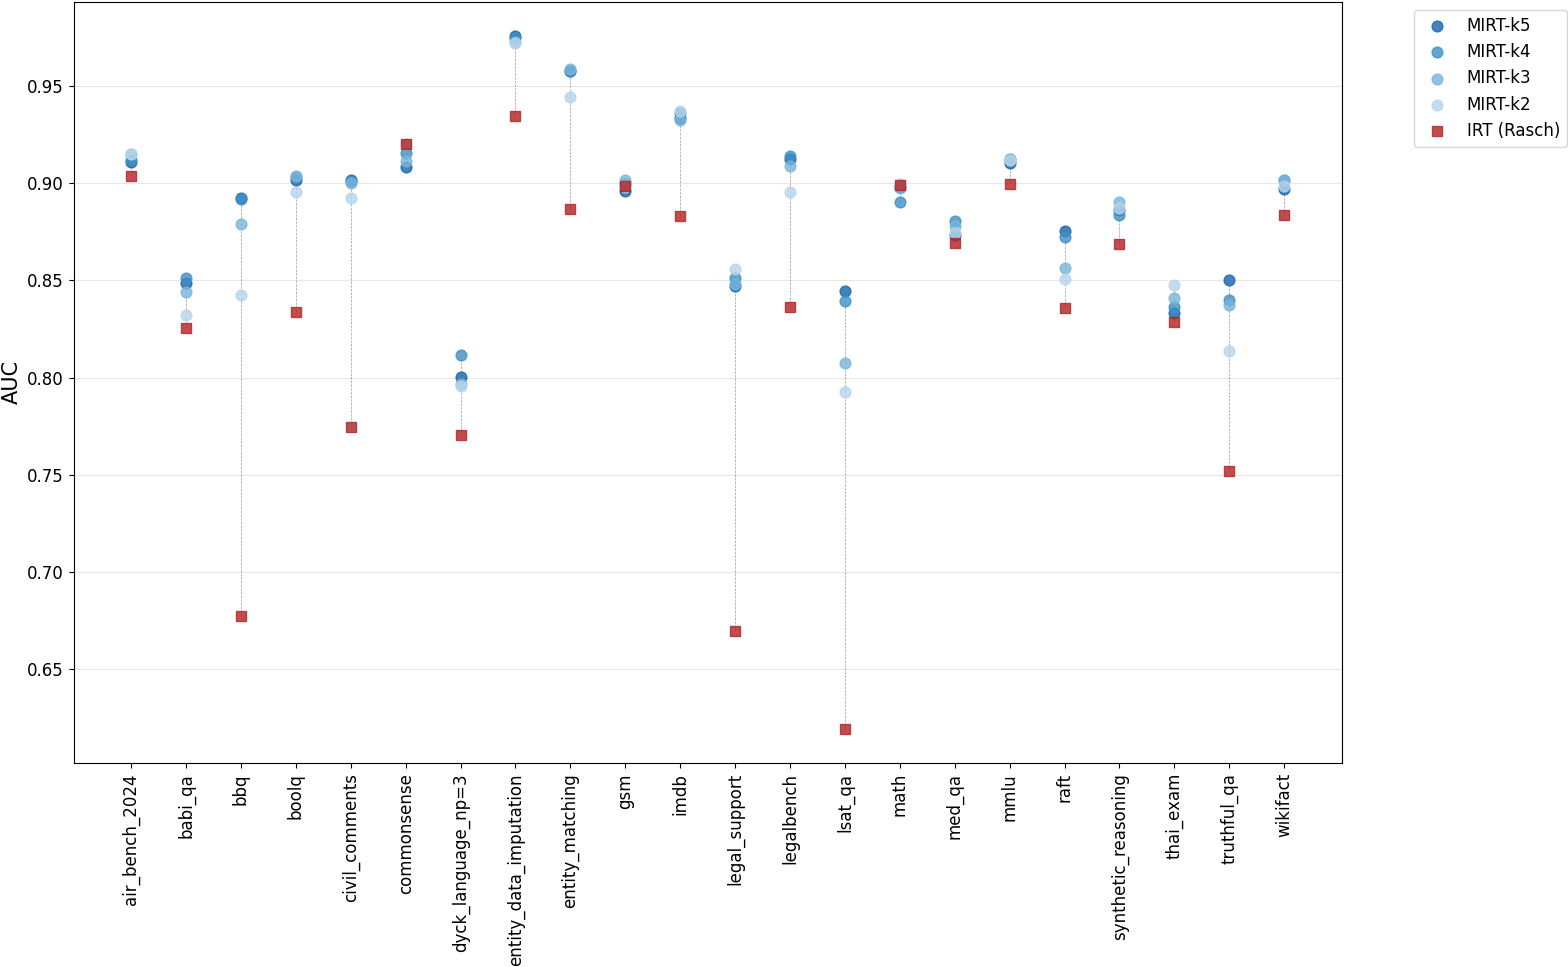

Plot shows 4 different k-factors with tab20b colors
K-factors: [np.int64(2), np.int64(3), np.int64(4), np.int64(5)]


In [20]:
import matplotlib.pyplot as plt
import sys
sys.path.append('..') 
import style

# Create the transposed dumbbell plot with k-factor colors
fig, ax = plt.subplots(figsize=(16, 10))

# Get unique scenarios and k-factors
scenarios = sorted(df['scenario'].unique())
k_factors = sorted(df['k_factor'].unique())

# Create a grayscale colormap that reflects numerical order
colors = plt.get_cmap('Blues')
# Use a subset of the colormap to avoid too light colors
color_map = {k: colors(0.3 + 0.5 * (i / max(1, len(k_factors) - 1))) for i, k in enumerate(k_factors)}

# Create x positions for each scenario
x_pos = {scenario: i for i, scenario in enumerate(scenarios)}

# Plot for each k-factor
for k_factor in reversed(k_factors):
	df_k = df[df['k_factor'] == k_factor]
	
	if len(df_k) == 0:
		continue
	
	# Get x positions for this k-factor's scenarios
	x_positions = [x_pos[scenario] for scenario in df_k['scenario']]
	
	# Plot the MIRT points
	ax.scatter(x_positions, df_k['mirt'], 
			  color=color_map[k_factor], s=60, 
			  label=f'MIRT-k{k_factor}', 
			  marker='o', alpha=0.8, zorder=3)

# Plot IRT (Rasch) points - same for all k-factors
# Get one representative IRT value per scenario (they should be the same across k-factors)
df_irt = df.groupby('scenario')['irt'].first().reset_index()
x_positions_irt = [x_pos[scenario] for scenario in df_irt['scenario']]

ax.scatter(x_positions_irt, df_irt['irt'], 
          color='firebrick', s=60, 
          label='IRT (Rasch)', 
          marker='s', alpha=0.8, zorder=3)
# Plot connecting lines between lowest and highest values for each scenario
for scenario in scenarios:
	df_scenario = df[df['scenario'] == scenario]
	if len(df_scenario) == 0:
		continue
	
	x = x_pos[scenario]
	
	# Get all values (both IRT and MIRT) for this scenario
	all_values = list(df_scenario['mirt']) + [df_scenario['irt'].iloc[0]]
	
	# Find min and max values
	min_val = min(all_values)
	max_val = max(all_values)
	
	# Draw line from lowest to highest value
	ax.plot([x, x], [min_val, max_val], 'k--', linewidth=0.5, alpha=0.4)

# Customize the plot
ax.set_xticks(range(len(scenarios)))
ax.set_xticklabels(scenarios, rotation=90)
ax.set_ylabel('AUC')
ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
ax.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Plot shows {len(k_factors)} different k-factors with tab20b colors")
print(f"K-factors: {k_factors}")